# Getting started with c50py: a credit model on mixed data

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/daviddiazsolis/c50py/blob/main/examples/notebooks/01_getting_started.ipynb)

Most business tables mix numbers and categories: the amount of a loan and its purpose, the age of
a customer and their housing situation. scikit-learn's trees only split on numbers, so the
categories have to be encoded first, usually one-hot. `c50py` implements Quinlan's C5.0, which
splits on categories directly: a test such as `purpose IN {new car, education}` is one question,
not a staircase of dummy variables.

This notebook takes the German credit data (1,000 loan applicants, 13 categorical and 7 numeric
columns, good or bad payer) from raw table to a model you can read, explain applicant by applicant,
and tune with the usual scikit-learn tools.

In [1]:
# Colab / a fresh environment: install c50py (0.5 or later)
import importlib, subprocess, sys
try:
    import c50py
    assert tuple(int(v) for v in c50py.__version__.split(".")[:2]) >= (0, 5)
except (ImportError, AssertionError):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--upgrade", "c50py>=0.5.0"], check=True)
    import c50py
    importlib.reload(c50py)
print("c50py", c50py.__version__)

c50py 0.5.0


In [2]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from c50py import C5Classifier

credit = fetch_openml(data_id=31, as_frame=True, parser="pandas")      # "credit-g"
X, y = credit.data, credit.target.astype(str)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)
print(X.dtypes.value_counts().to_string())
X.head(3)

int64       7
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,4,real estate,67,none,own,2,skilled,1,yes,yes
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,2,real estate,22,none,own,1,skilled,1,none,yes
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes


## 1. Fit, with no preprocessing

The DataFrame goes in as it is. `c50py` treats `category`, `object`, `string` and `bool` columns as
categorical (`infer_categorical=True`, the default), uses the column names in its output, and
handles missing values on its own. The defaults are C5.0's: confidence factor `cf=0.25` for
pruning and at least two cases per leaf.

In [3]:
tree = C5Classifier().fit(X_train, y_train)
print("categorical columns detected:", [tree.feature_names_[j] for j in tree.categorical_features_])
print(f"leaves: {len(tree.export_rules())}   test accuracy: {tree.score(X_test, y_test):.3f}")

categorical columns detected: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']
leaves: 59   test accuracy: 0.720


## 2. Read it

`plot_tree` draws the tree with the same function, arguments and layout as
`sklearn.tree.plot_tree`; categorical tests read `feature in {a, b}` (the left, `True`, branch holds
the listed categories). Boxes use c50py's own palette so a C5.0 tree is easy to tell apart from a
CART tree. `max_depth` limits the drawing, not the model.

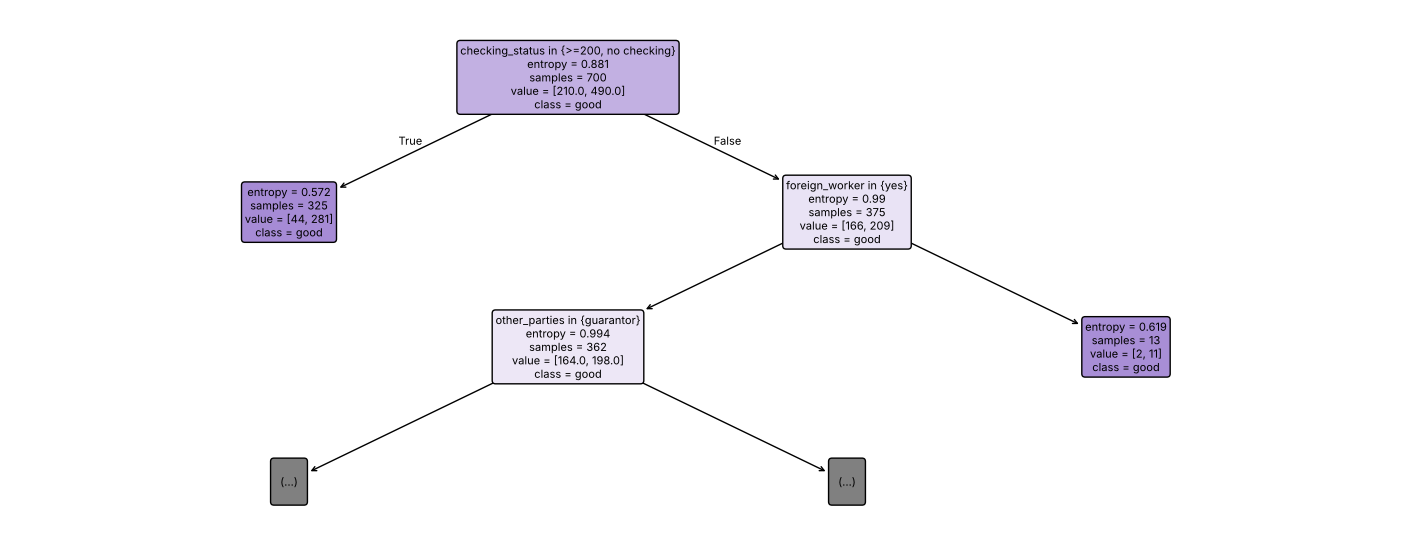

In [4]:
fig, ax = plt.subplots(figsize=(18, 7))
tree.plot_tree(max_depth=2, class_names=list(tree.classes_), filled=True, rounded=True, fontsize=8, ax=ax)
plt.show()

The same tree as text, and as rules: every leaf is a rule, the conjunction of the tests on its
path. These are the **rules of the tree**: they are mutually exclusive, so every applicant follows
exactly one. (A shorter, simplified **ruleset** in the style of C5.0 is in notebook 04.)

In [5]:
for rule in tree.export_rules()[:8]:
    print(rule)

checking_status IN {>=200, no checking} => good
checking_status NOT IN {>=200, no checking} AND foreign_worker IN {yes} AND other_parties IN {guarantor} AND other_payment_plans IN {none} AND duration <= 37.5000 => good
checking_status NOT IN {>=200, no checking} AND foreign_worker IN {yes} AND other_parties IN {guarantor} AND other_payment_plans IN {none} AND duration > 37.5000 => bad
checking_status NOT IN {>=200, no checking} AND foreign_worker IN {yes} AND other_parties IN {guarantor} AND other_payment_plans NOT IN {none} => bad
checking_status NOT IN {>=200, no checking} AND foreign_worker IN {yes} AND other_parties NOT IN {guarantor} AND savings_status IN {100<=X<500, <100} AND duration <= 43.5000 AND credit_history IN {all paid, no credits/all paid} AND other_payment_plans IN {bank} AND savings_status IN {<100} AND residence_since <= 2.5000 => good
checking_status NOT IN {>=200, no checking} AND foreign_worker IN {yes} AND other_parties NOT IN {guarantor} AND savings_status IN {1

## 3. Explain each decision

For a credit committee the question is not only "good or bad?" but "why?". `apply_rules(X)` gives,
for every applicant, the rule they follow (its number, its text and the prediction), indexed like
the input; `predict_proba` gives the probability of each class, which is the share of training
applicants of that class in the leaf.

In [6]:
explained = tree.apply_rules(X_test.head(5))
explained["P(bad)"] = tree.predict_proba(X_test.head(5))[:, list(tree.classes_).index("bad")].round(2)
explained["actual"] = y_test.head(5).values
pd.set_option("display.max_colwidth", 140)
explained

,rule_id,rule,prediction,P(bad),actual
919,33,"checking_status NOT IN {>=200, no checking} AND foreign_worker IN {yes} AND other_parties NOT IN {guarantor} AND savings_status IN {100<...",good,0.00,bad
125,10,"checking_status NOT IN {>=200, no checking} AND foreign_worker IN {yes} AND other_parties NOT IN {guarantor} AND savings_status IN {100<...",bad,0.83,good
913,0,"checking_status IN {>=200, no checking}",good,0.14,good
657,0,"checking_status IN {>=200, no checking}",good,0.14,good
116,46,"checking_status NOT IN {>=200, no checking} AND foreign_worker IN {yes} AND other_parties NOT IN {guarantor} AND savings_status NOT IN {...",good,0.00,bad


## 4. Missing values

C5.0 does not need imputation. When a value is missing, the case goes down both branches of the
test with fractional weights, proportional to how the training cases split (this is why the
`samples` in some boxes can have decimals). Here we blank out 15% of the values of the test set and
compare with filling the gaps with the most frequent value or the median.

In [7]:
rng = np.random.default_rng(0)
X_missing = X_test.copy()
for c in X_missing.columns:
    X_missing.loc[rng.random(len(X_missing)) < 0.15, c] = np.nan

X_filled = X_missing.copy()
for c in X_filled.columns:
    fill = X_train[c].mode()[0] if str(X_train[c].dtype) == "category" else X_train[c].median()
    X_filled[c] = X_filled[c].fillna(fill)

print(f"complete test data:                {tree.score(X_test, y_test):.3f}")
print(f"15% missing, c50py as is:          {tree.score(X_missing, y_test):.3f}")
print(f"15% missing, filled (mode/median): {tree.score(X_filled, y_test):.3f}")

complete test data:                0.720
15% missing, c50py as is:          0.707
15% missing, filled (mode/median): 0.720


On this data the two ways of dealing with the gaps give about the same accuracy (a difference of
a few applicants out of 300), which is the common case. What fractional propagation buys is not
accuracy but simplicity and honesty: no fill rule to choose and maintain, the same model for
complete and incomplete rows, and probabilities that reflect that a value was unknown instead of
pretending it was the median. Notebook 05 looks at this more closely.

## 5. It is a scikit-learn estimator

`C5Classifier` passes scikit-learn's `check_estimator`, so it works with `clone`, `Pipeline`,
`cross_val_score` and `GridSearchCV`. The parameter that matters most is `cf`, the confidence
factor of the pessimistic pruning: smaller values prune more.

In [8]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

grid = GridSearchCV(C5Classifier(), {"cf": [0.05, 0.1, 0.25, 0.5], "min_samples_leaf": [2, 5, 10]},
                    cv=StratifiedKFold(5, shuffle=True, random_state=0))
grid.fit(X_train, y_train)
best = grid.best_estimator_
print("best parameters:", grid.best_params_)
print(f"leaves: {len(best.export_rules())}   test accuracy: {best.score(X_test, y_test):.3f}")

best parameters: {'cf': 0.05, 'min_samples_leaf': 2}
leaves: 16   test accuracy: 0.757


Credit data are noisy, and cross-validation asks for much more pruning than C5.0's default: the
tuned tree is a fraction of the size of the default one and more accurate on the test set.
Choosing `cf` by cross-validation is worth it whenever the tree is meant to be read. Its rules:

In [9]:
for rule in best.export_rules():
    print(rule)

checking_status IN {>=200, no checking} => good
checking_status NOT IN {>=200, no checking} AND other_parties IN {guarantor} => good
checking_status NOT IN {>=200, no checking} AND other_parties NOT IN {guarantor} AND savings_status IN {100<=X<500, <100} AND duration <= 43.5000 AND credit_history IN {all paid, no credits/all paid} => bad
checking_status NOT IN {>=200, no checking} AND other_parties NOT IN {guarantor} AND savings_status IN {100<=X<500, <100} AND duration <= 43.5000 AND credit_history NOT IN {all paid, no credits/all paid} AND duration <= 11.5000 => good
checking_status NOT IN {>=200, no checking} AND other_parties NOT IN {guarantor} AND savings_status IN {100<=X<500, <100} AND duration <= 43.5000 AND credit_history NOT IN {all paid, no credits/all paid} AND duration > 11.5000 AND credit_history IN {critical/other existing credit} => good
checking_status NOT IN {>=200, no checking} AND other_parties NOT IN {guarantor} AND savings_status IN {100<=X<500, <100} AND duration

## 6. Two more C5.0 options

* `winnow=True`: C5.0's feature selection. A trial tree is grown on half of the training data;
  columns it never uses, or that make its errors on the other half worse, are dropped before the
  final tree is grown. The dropped columns are listed in `winnowed_features_`.
* `trials=10`: C5.0's boosting. Ten trees are grown in sequence, each one paying more attention to
  the cases the previous ones got wrong, and they vote. More accurate, but the single readable tree
  is gone.

In [10]:
winnowed = C5Classifier(winnow=True).fit(X_train, y_train)
print("dropped by winnowing:", winnowed.winnowed_features_)
print(f"winnowed tree: {len(winnowed.export_rules())} leaves, test accuracy {winnowed.score(X_test, y_test):.3f}")

boosted = C5Classifier(trials=10).fit(X_train, y_train)
print(f"boosted ({len(boosted.ensemble_)} trees): test accuracy {boosted.score(X_test, y_test):.3f}")

dropped by winnowing: ['credit_amount', 'installment_commitment', 'age', 'other_payment_plans', 'own_telephone']
winnowed tree: 59 leaves, test accuracy 0.720


boosted (10 trees): test accuracy 0.740


Winnowing drops several columns without changing the accuracy here, which makes the model cheaper
to apply and easier to explain (fewer variables to collect and justify). Boosting gains a couple of
points over the single default tree, at the price of the single readable tree.

## Where to go next

* `02_c50py_vs_cart.ipynb`: the same data with scikit-learn's CART and one-hot encoding, side by side.
* `03_c50py_vs_gradient_boosting.ipynb`: how much accuracy a readable tree gives up against
  gradient boosting, and when it does not.
* `04_rules_rulesets_churn_campaigns.ipynb`: rules of the tree and C5.0 rulesets, turned into
  retention campaigns.
* `05_missing_values_and_winnowing.ipynb`: the two C5.0 mechanisms in more detail.